# Sequence Problem in Text Recognition

## The Core Challenge: Text is a 1D Sequence in 2D Space

### Understanding the Problem:
- **Text Layout**: Characters are arranged horizontally (left-to-right)
- **Sequential Nature**: Order matters - "CAT" ≠ "TAC" ≠ "ACT"
- **2D Representation**: Text appears as pixels in a 2D image
- **Challenge**: Extract 1D sequence from 2D spatial data

### Why This Matters:
Traditional computer vision treats images as spatial patterns, but text requires understanding temporal/sequential relationships.

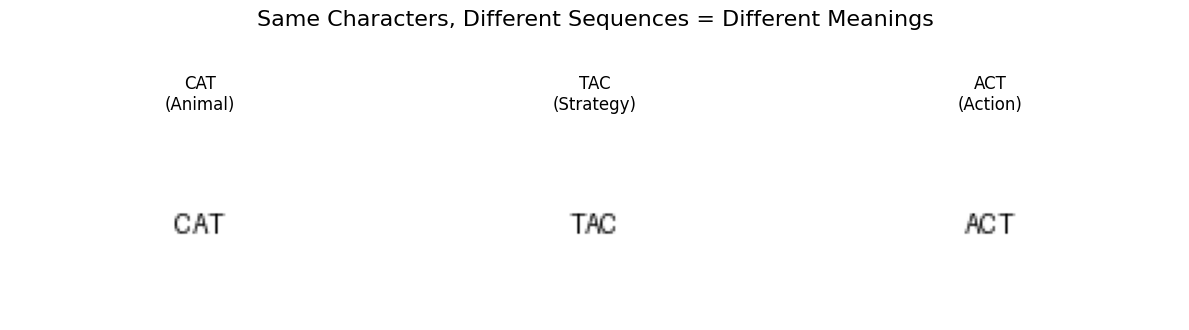

Key Insight: Character order completely changes meaning!
This is why we need sequence modeling for text recognition.


In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

def create_text_image(text, size=(300, 80), font_size=32):
    """Create a text image for demonstration"""
    img = Image.new('RGB', size, color='white')
    draw = ImageDraw.Draw(img)

    try:
        font = ImageFont.truetype("arial.ttf", font_size)
    except:
        font = ImageFont.load_default()

    # Center the text
    bbox = draw.textbbox((0, 0), text, font=font)
    text_width = bbox[2] - bbox[0]
    text_height = bbox[3] - bbox[1]

    x = (size[0] - text_width) // 2
    y = (size[1] - text_height) // 2

    draw.text((x, y), text, fill='black', font=font)
    return img

# Demonstrate the sequence problem
def demonstrate_sequence_importance():
    """Show how character order affects meaning"""

    # Same characters, different orders
    sequences = ["CAT", "TAC", "ACT"]
    meanings = ["Animal", "Strategy", "Action"]

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    for i, (seq, meaning) in enumerate(zip(sequences, meanings)):
        img = create_text_image(seq, size=(150, 80), font_size=24)
        axes[i].imshow(img)
        axes[i].set_title(f'{seq}\n({meaning})')
        axes[i].axis('off')

    plt.suptitle('Same Characters, Different Sequences = Different Meanings', fontsize=16)
    plt.tight_layout()
    plt.show()

demonstrate_sequence_importance()

print("Key Insight: Character order completely changes meaning!")
print("This is why we need sequence modeling for text recognition.")

## Visual Representation of the Sequence Problem

### How Humans Read Text:
1. **Scan from left to right** (in English)
2. **Recognize character shapes** (spatial processing)
3. **Combine characters into words** (sequence processing)
4. **Apply language knowledge** (context understanding)

### How Traditional OCR Works:
1. **Segment characters** (find boundaries)
2. **Classify each character** (spatial processing only)
3. **Concatenate results** (no sequence understanding)
4. **Apply post-processing** (spell check, language model)

## The Need for Implicit Sequence Modeling

### Problems with Explicit Segmentation:
1. **Connected Characters**: Letters may touch or overlap
2. **Variable Spacing**: Inconsistent gaps between characters
3. **Cursive Text**: Handwritten text with flowing connections
4. **Noise and Distortion**: Poor image quality affects segmentation

### Solution: Implicit Sequence Modeling
Instead of explicitly segmenting characters, we:
1. **Extract spatial features** across the entire text image
2. **Model sequences** without explicit boundaries
3. **Learn alignment** between features and characters automatically
4. **Handle variable lengths** naturally

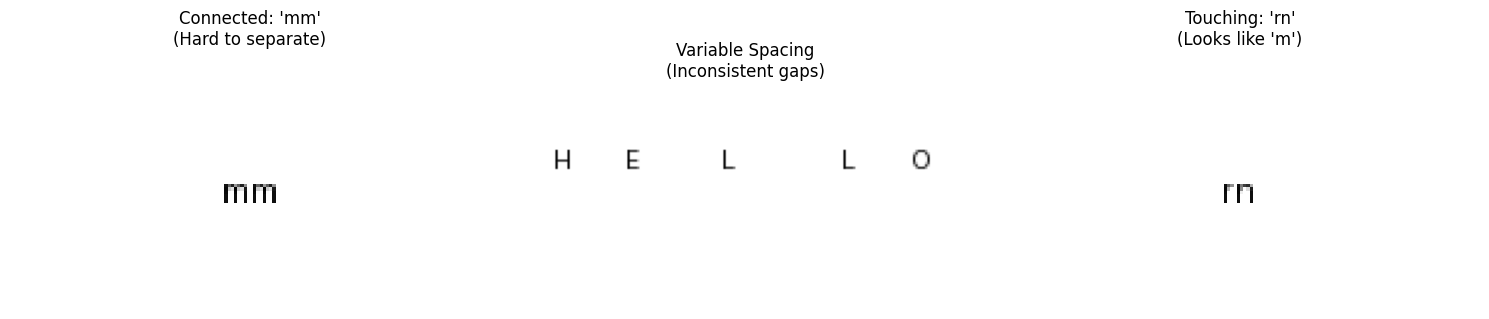

Traditional Segmentation Challenges:

1. Connected Characters:
   - 'mm' → Where does first 'm' end?
   - 'rn' → Could be mistaken for 'm'

2. Variable Spacing:
   - Inconsistent gaps between letters
   - Hard to determine optimal segmentation points

3. Font Variations:
   - Different fonts have different character widths
   - Cursive/handwritten text has connections

Solution: Models that can handle sequences implicitly!


In [2]:
# Demonstrate challenging segmentation scenarios

def create_challenging_segmentation_examples():
    """Create examples where traditional segmentation fails"""

    # Example 1: Connected characters
    connected_img = create_text_image("mm", size=(150, 80), font_size=36)

    # Example 2: Variable spacing
    spaced_img = Image.new('RGB', (200, 80), color='white')
    draw = ImageDraw.Draw(spaced_img)
    try:
        font = ImageFont.truetype("arial.ttf", 24)
    except:
        font = ImageFont.load_default()

    # Draw letters with varying spacing
    positions = [20, 50, 90, 140, 170]
    letters = "H E L L O"
    for i, (pos, letter) in enumerate(zip(positions, letters.split())):
        draw.text((pos, 25), letter, fill='black', font=font)

    # Example 3: Overlapping/touching characters
    touching_img = create_text_image("rn", size=(150, 80), font_size=36)  # 'rn' can look like 'm'

    # Display examples
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    examples = [
        (connected_img, "Connected: 'mm'\n(Hard to separate)"),
        (spaced_img, "Variable Spacing\n(Inconsistent gaps)"),
        (touching_img, "Touching: 'rn'\n(Looks like 'm')")
    ]

    for i, (img, title) in enumerate(examples):
        axes[i].imshow(img)
        axes[i].set_title(title)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

    return connected_img, spaced_img, touching_img

conn_img, space_img, touch_img = create_challenging_segmentation_examples()

print("Traditional Segmentation Challenges:")
print("")
print("1. Connected Characters:")
print("   - 'mm' → Where does first 'm' end?")
print("   - 'rn' → Could be mistaken for 'm'")
print("")
print("2. Variable Spacing:")
print("   - Inconsistent gaps between letters")
print("   - Hard to determine optimal segmentation points")
print("")
print("3. Font Variations:")
print("   - Different fonts have different character widths")
print("   - Cursive/handwritten text has connections")
print("")
print("Solution: Models that can handle sequences implicitly!")

## From Spatial to Sequential: The Paradigm Shift

### Traditional Computer Vision Approach:
```
Image → Features → Classification
```

### Text Recognition Requirement:
```
Image → Spatial Features → Sequential Features → Text Sequence
```

### The Key Insight:
We need models that can:
1. **Extract spatial features** (what CNN does well)
2. **Model sequential dependencies** (what RNN does well)
3. **Align features with text** (what CTC loss enables)
4. **Handle variable lengths** (what makes it practical)

### Next Step: CRNN Architecture
The solution combines:
- **CNN layers** for spatial feature extraction
- **RNN layers** for sequence modeling
- **CTC loss** for alignment learning

This creates an end-to-end system that can handle the sequence problem in text recognition!

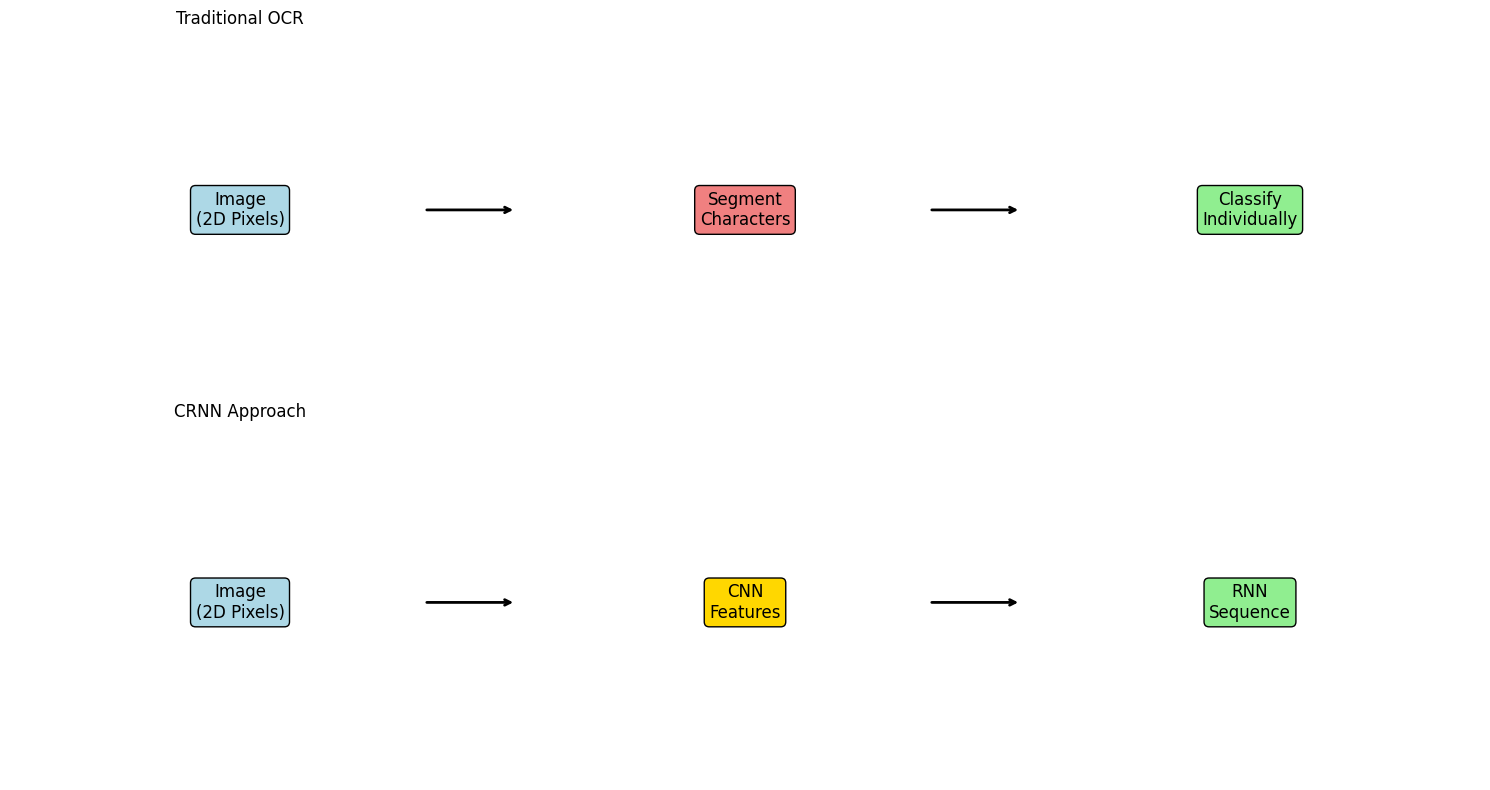

Paradigm Shift Summary:

Traditional OCR:
✗ Requires explicit character segmentation
✗ Processes characters independently
✗ Fragile to segmentation errors

CRNN Approach:
✓ Implicit sequence modeling
✓ End-to-end learning
✓ Handles variable lengths
✓ Robust to character variations

Next: Let's see how CRNN architecture solves these problems!


In [3]:
# Conceptual visualization of the paradigm shift

def visualize_paradigm_shift():
    """Show the difference between spatial and sequential approaches"""

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))

    # Traditional approach (top row)
    axes[0, 0].text(0.5, 0.5, 'Image\n(2D Pixels)', ha='center', va='center',
                   fontsize=12, bbox=dict(boxstyle='round', facecolor='lightblue'))
    axes[0, 0].set_xlim(0, 1)
    axes[0, 0].set_ylim(0, 1)
    axes[0, 0].set_title('Traditional OCR')
    axes[0, 0].axis('off')

    axes[0, 1].text(0.5, 0.5, 'Segment\nCharacters', ha='center', va='center',
                   fontsize=12, bbox=dict(boxstyle='round', facecolor='lightcoral'))
    axes[0, 1].set_xlim(0, 1)
    axes[0, 1].set_ylim(0, 1)
    axes[0, 1].axis('off')

    axes[0, 2].text(0.5, 0.5, 'Classify\nIndividually', ha='center', va='center',
                   fontsize=12, bbox=dict(boxstyle='round', facecolor='lightgreen'))
    axes[0, 2].set_xlim(0, 1)
    axes[0, 2].set_ylim(0, 1)
    axes[0, 2].axis('off')

    # CRNN approach (bottom row)
    axes[1, 0].text(0.5, 0.5, 'Image\n(2D Pixels)', ha='center', va='center',
                   fontsize=12, bbox=dict(boxstyle='round', facecolor='lightblue'))
    axes[1, 0].set_xlim(0, 1)
    axes[1, 0].set_ylim(0, 1)
    axes[1, 0].set_title('CRNN Approach')
    axes[1, 0].axis('off')

    axes[1, 1].text(0.5, 0.5, 'CNN\nFeatures', ha='center', va='center',
                   fontsize=12, bbox=dict(boxstyle='round', facecolor='gold'))
    axes[1, 1].set_xlim(0, 1)
    axes[1, 1].set_ylim(0, 1)
    axes[1, 1].axis('off')

    axes[1, 2].text(0.5, 0.5, 'RNN\nSequence', ha='center', va='center',
                   fontsize=12, bbox=dict(boxstyle='round', facecolor='lightgreen'))
    axes[1, 2].set_xlim(0, 1)
    axes[1, 2].set_ylim(0, 1)
    axes[1, 2].axis('off')

    # Add arrows
    for i in range(2):
        for j in range(2):
            axes[i, j].annotate('', xy=(1.1, 0.5), xytext=(0.9, 0.5),
                               arrowprops=dict(arrowstyle='->', lw=2, color='black'),
                               xycoords='axes fraction', textcoords='axes fraction')

    plt.tight_layout()
    plt.show()

visualize_paradigm_shift()

print("Paradigm Shift Summary:")
print("")
print("Traditional OCR:")
print("✗ Requires explicit character segmentation")
print("✗ Processes characters independently")
print("✗ Fragile to segmentation errors")
print("")
print("CRNN Approach:")
print("✓ Implicit sequence modeling")
print("✓ End-to-end learning")
print("✓ Handles variable lengths")
print("✓ Robust to character variations")
print("")
print("Next: Let's see how CRNN architecture solves these problems!")